# Sales Forecasting by Category with LSTM

## Project Overview

This notebook documents an LSTM-based forecasting workflow to predict daily sales volume by product category for a craft brewery operation.

## Problem Definition

The business requires category-level demand forecasts to improve operational planning, including procurement, production, and staffing. The challenge is to model non-linear temporal behavior with strong weekly seasonality and category-specific volatility.

## Data Description

The modeling dataset covers 2022-2024 and is aggregated by day and category. Date-derived features are included to capture calendar effects and seasonality.

## Methodology

The approach combines sequence modeling, temporal split validation, and category-level error analysis. A baseline model is first tuned on the highest-volume category, then transferred as a practical configuration to all target categories.

## Implementation

Implementation uses TensorFlow/Keras LSTM layers, scaling pipelines, early stopping, and error diagnostics (MAE, RMSE, R²) at both aggregate and category levels.

## Results and Analysis

The models learn baseline temporal structure but systematically underpredict high-demand peaks in several categories.

## Key Insights

Category heterogeneity is the dominant source of performance variation; one shared configuration is operationally efficient but suboptimal for low-signal categories.

## Conclusion

LSTM provides a credible baseline, but category-specific tuning and richer exogenous features are required for production-grade accuracy.


## Implementation Setup

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import random
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (mean_absolute_error,
                             root_mean_squared_error,
                             r2_score)
import time

import tensorflow as tf

from keras.models import Sequential
from keras.layers import Input, LSTM, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import keras

In [2]:
# Set the random seeds
seed_value = 102
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ['PYTHONHASHSEED'] = str(seed_value)

## Reusable Functions

### Visualization Utilities

In [3]:
paleta = ['#aabd4a', '#6b282e', '#01ab7d',
              '#f2a00f', '#f1cc1c', '#f8643c',
              '#fe99a9ff', '#6b282edd', '#9e87c8'
              ]

In [4]:
def plot_ventas_por_categoria(
    df,
    col_fecha='fecha',
    col_valor='cantidad',
    col_categoria='categoria',
    categorias=None,
    n_cols=2,
    figsize=(18, 12)
):


    # Select categories
    if categorias is None:
        categorias = df[col_categoria].unique()

    n = len(categorias)
    n_rows = (n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=True)
    axes = axes.flatten()

    for i, cat in enumerate(categorias):
        ax = axes[i]
        df_cat = df[df[col_categoria] == cat].sort_values(col_fecha)

        sns.lineplot(
            data=df_cat,
            x=col_fecha,
            y=col_valor,
            ax=ax,
            color=paleta[i % len(paleta)],
        )
        ax.tick_params(axis='x', labelbottom=True)
        ax.set_title(str(cat), fontsize=12)
        ax.set_xlabel("")
        ax.set_ylabel("Valor diario")

    # Turn off empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.legend()
    plt.tight_layout()
    plt.show()


In [5]:
def plot_time_sums_by_category(df, categoria_col, time_columns, value_col,
                               figsize_factor_x=5, figsize_factor_y=4,
                               rotation=45, palette="pastel"):
    """
    Genera un grid de barplots donde:
    - Filas = categorías
    - Columnas = variables temporales
    - La altura de la barra = suma de value_col (ej: ventas)
    """

    categorias = df[categoria_col].unique()
    n_rows = len(categorias)
    n_cols = len(time_columns)

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(figsize_factor_x * n_cols, figsize_factor_y * n_rows),
        squeeze=False
    )

    sns.set(style="whitegrid")

    for i, cat in enumerate(categorias):

        df_cat = df[df[categoria_col] == cat]

        for j, col in enumerate(time_columns):

            ax = axes[i, j]

            # Group and add
            df_sum = (
                df_cat.groupby(col, as_index=False, observed=False)[value_col]
                .sum()
                .sort_values(col)
            )

            sns.barplot(
                data=df_sum,
                x=col,
                y=value_col,
                color=paleta[i % len(paleta)],
                ax=ax
            )

            ax.set_title(f"{col} — {cat}", fontsize=12)
            ax.set_xlabel(col)
            ax.set_ylabel(f"Suma de {value_col}")
            ax.tick_params(axis="x", rotation=rotation)

    plt.tight_layout()
    plt.show()

In [6]:
def plot_predicciones_por_categoria(
    df_pred,
    col_fecha='fecha',
    col_valor_real='y_real',
    col_valor_pred='y_pred',
    col_categoria='categoria',
    categorias=None,
    n_cols=2,
    figsize=(18, 12),
    paleta=paleta
):
    """
    Grafica predicciones vs valores reales por categoría en subplots.
    Cada subplot muestra una categoría.
    """
    # Ensure columns are of the correct type
    col_fecha = str(col_fecha)
    col_categoria = str(col_categoria)
    col_valor_real = str(col_valor_real)
    col_valor_pred = str(col_valor_pred)

    df_pred = df_pred.copy()
    df_pred[col_categoria] = df_pred[col_categoria].astype(str)
    df_pred[col_fecha] = pd.to_datetime(df_pred[col_fecha])

    if paleta is None:
        paleta = sns.color_palette("tab10")

    # Select categories
    if categorias is None:
        categorias = df_pred[col_categoria].unique()

    n = len(categorias)
    n_rows = (n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=True)
    axes = axes.flatten()

    for i, cat in enumerate(categorias):
        ax = axes[i]
        df_cat = df_pred[df_pred[col_categoria] == cat].sort_values(col_fecha)

        # Real value line
        sns.lineplot(
            data=df_cat,
            x=col_fecha,
            y=col_valor_real,
            ax=ax,
            color='grey',
            legend=False
        )
        # Predictions line
        sns.lineplot(
            data=df_cat,
            x=col_fecha,
            y=col_valor_pred,
            ax=ax,
            color=paleta[i],
            legend=False
        )

        ax.set_title(str(cat), fontsize=12)
        ax.set_xlabel("")
        ax.set_ylabel("Cantidad")
        ax.grid(False)

        # Rotate dates
        plt.setp(ax.get_xticklabels(), rotation=45)

        # # Reduce ticks if there are many dates
        # ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=6))

    # Turn off empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


### Category-Specific Training Utilities

In [7]:
def preprocess_data_por_cat(df,
                            categoria,
                            cutoff_date,
                            sequence_length=15,
                            use_log=False):

    # Filter category
    df_cat = df[df['categoria'] == categoria].sort_values('fecha').reset_index(drop=True)
    df_cat['fecha'] = pd.to_datetime(df_cat['fecha'])

    # Split by date
    train_df = df_cat[df_cat['fecha'] <= cutoff_date].copy()
    test_df  = df_cat[df_cat['fecha'] >  cutoff_date].copy()

    if use_log:
        train_df["cantidad"] = np.log1p(train_df["cantidad"])
        test_df["cantidad"]  = np.log1p(test_df["cantidad"])

    # Climb only using TRAIN
    scaler = MinMaxScaler()
    scaler.fit(train_df[features])

    train_scaled = scaler.transform(train_df[features])
    test_scaled  = scaler.transform(test_df[features])

    # Function to create sequences
    def create_sequences(data_scaled, df_dates):
        X, y, fechas = [], [], []
        for i in range(len(data_scaled) - sequence_length):
            X.append(data_scaled[i:i + sequence_length])
            y.append(data_scaled[i + sequence_length][0])
            fechas.append(df_dates.iloc[i + sequence_length])
        return np.array(X), np.array(y), pd.Series(fechas).reset_index(drop=True)

    X_train, y_train, fechas_train = create_sequences(train_scaled,
                                                      train_df['fecha'])
    X_test,  y_test,  fechas_test  = create_sequences(test_scaled,
                                                      test_df['fecha'])

    return X_train, X_test, y_train, y_test, scaler, fechas_test

In [8]:
def model_fit_por_categoria(
    X_train, X_test, y_train, y_test, fechas_test,
    sequence_length, n_features,
    scaler, categoria, epochs=75, batch_size=10,
    use_log=False):

    # Model definition
    model = Sequential([
        Input(shape=(sequence_length, n_features)),
        LSTM(32, return_sequences=True),
        LSTM(16),
        Dense(1)
    ])

    model.compile(loss='mse', optimizer=Adam(0.001))

    # Early stopping
    early = EarlyStopping(patience=10, restore_best_weights=True)

    # Training
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early],
        verbose=0
    )

    plt.figure(figsize=(7, 4))

    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.title(f'Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()
    # MSE Assessment
    mse = model.evaluate(X_test, y_test, verbose=0)

    # Prediction
    train_predict = model.predict(X_train, verbose=0)
    test_predict = model.predict(X_test, verbose=0)

    # Reversal of scaling
    y_train_sc = scaler.inverse_transform(
        np.hstack([
            y_train.reshape(-1, 1),
            np.zeros((len(y_train), n_features - 1))
        ])
    )[:, 0]

    y_test_sc = scaler.inverse_transform(
        np.hstack([
            y_test.reshape(-1, 1),
            np.zeros((len(y_test), n_features - 1))
        ])
    )[:, 0]

    train_predict_sc = scaler.inverse_transform(
        np.hstack([
            train_predict.reshape(-1, 1),
            np.zeros((len(train_predict), n_features - 1))
        ])
    )[:, 0]

    test_predict_sc = scaler.inverse_transform(
        np.hstack([
            test_predict.reshape(-1, 1),
            np.zeros((len(test_predict), n_features - 1))
        ])
    )[:, 0]

    if use_log:
        y_train_sc = np.expm1(y_train_sc)
        y_test_sc  = np.expm1(y_test_sc)
        train_predict_sc = np.expm1(train_predict_sc)
        test_predict_sc  = np.expm1(test_predict_sc)

    # ---- MAE calculation ----
    mae_train = mean_absolute_error(y_train_sc, train_predict_sc)
    mae_test = mean_absolute_error(y_test_sc, test_predict_sc)

    # ---- RMSE calculation ----
    rmse_train = root_mean_squared_error(y_train_sc, train_predict_sc)
    rmse_test = root_mean_squared_error(y_test_sc, test_predict_sc)

    # ---- Calculation of R2 ----
    r2_train = r2_score(y_train_sc, train_predict_sc)
    r2_test = r2_score(y_test_sc, test_predict_sc)

    # DataFrame with predictions and actuals
    df_pred = pd.DataFrame({
        'categoria': categoria,
        'fecha': fechas_test,
        'y_real': y_test_sc,
        'y_pred': test_predict_sc
    })

    # Saving the model
    nombre_archivo = f"model_{categoria.replace(' ', '_')}.keras"
    model.save(nombre_archivo)

    return mse, mae_test, rmse_test, r2_test, df_pred


## Data Description and Preparation

In [9]:
# Pandas is imported previously to read the file from Drive.
# The dataset to be worked on must be stored in /content/drive/My Drive/Notebooks/
# Under the proposed route

ruta = 'datos/'
# sales_model_file = 'df_model.xlsx'
archivo_ventas_modelo = 'df_model_full.xlsx'
df = pd.read_excel(ruta + archivo_ventas_modelo)

In [10]:
df_model = df.copy()

In [11]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 9828 entries, 0 to 9827
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   fecha          9828 non-null   datetime64[us]
 1   categoria      9828 non-null   str           
 2   año            9828 non-null   int64         
 3   mes            9828 non-null   int64         
 4   dia_del_mes    9828 non-null   int64         
 5   dia_semana     9828 non-null   str           
 6   decadre        9828 non-null   int64         
 7   fin_de_semana  9828 non-null   bool          
 8   holiday        9828 non-null   int64         
 9   cantidad       9828 non-null   float64       
dtypes: bool(1), datetime64[us](1), float64(1), int64(5), str(2)
memory usage: 700.8 KB


In [12]:
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df_model["dia_semana"] = pd.Categorical(
    df_model["dia_semana"],
    categories=orden_dias,
    ordered=True
)

In [13]:
df_model.head()

,fecha,categoria,año,mes,dia_del_mes,dia_semana,decadre,fin_de_semana,holiday,cantidad
0,2022-01-03,Bebidas sin alcohol,2022,1,3,Monday,1,False,0,4.0
1,2022-01-03,Hamburguesas,2022,1,3,Monday,1,False,0,15.0
2,2022-01-03,Latas,2022,1,3,Monday,1,False,0,1.0
3,2022-01-03,Otras Bebidas,2022,1,3,Monday,1,False,0,21.0
4,2022-01-03,Papas,2022,1,3,Monday,1,False,0,10.0


In [14]:
df_model.columns

Index(['fecha', 'categoria', 'año', 'mes', 'dia_del_mes', 'dia_semana',
       'decadre', 'fin_de_semana', 'holiday', 'cantidad'],
      dtype='str')

### Category-Level Baseline Comparison

/var/folders/xg/vfv21kq10ml9ntw2tx_bysq00000gn/T/ipykernel_17560/865618055.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


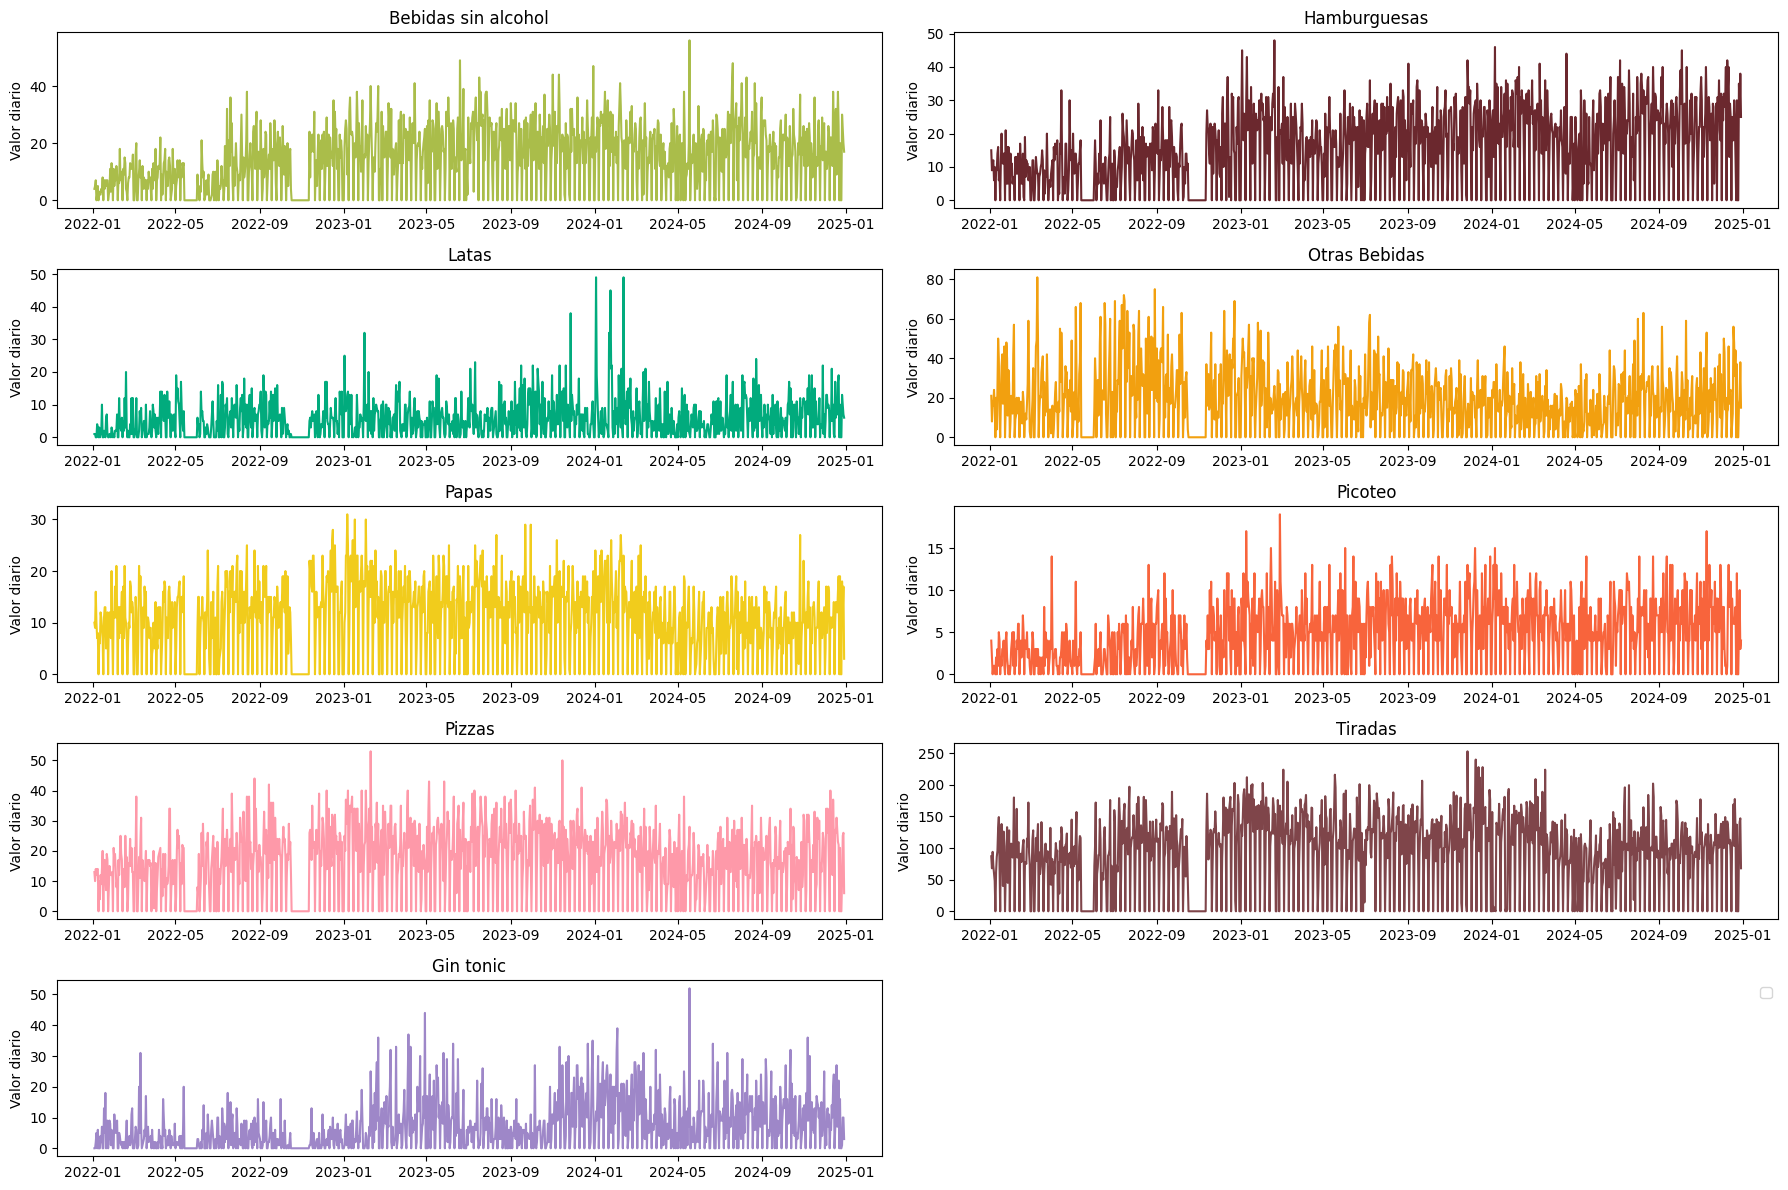

In [15]:
plot_ventas_por_categoria(
    df_model,
    col_fecha='fecha',
    col_valor='cantidad',
    col_categoria='categoria'
)

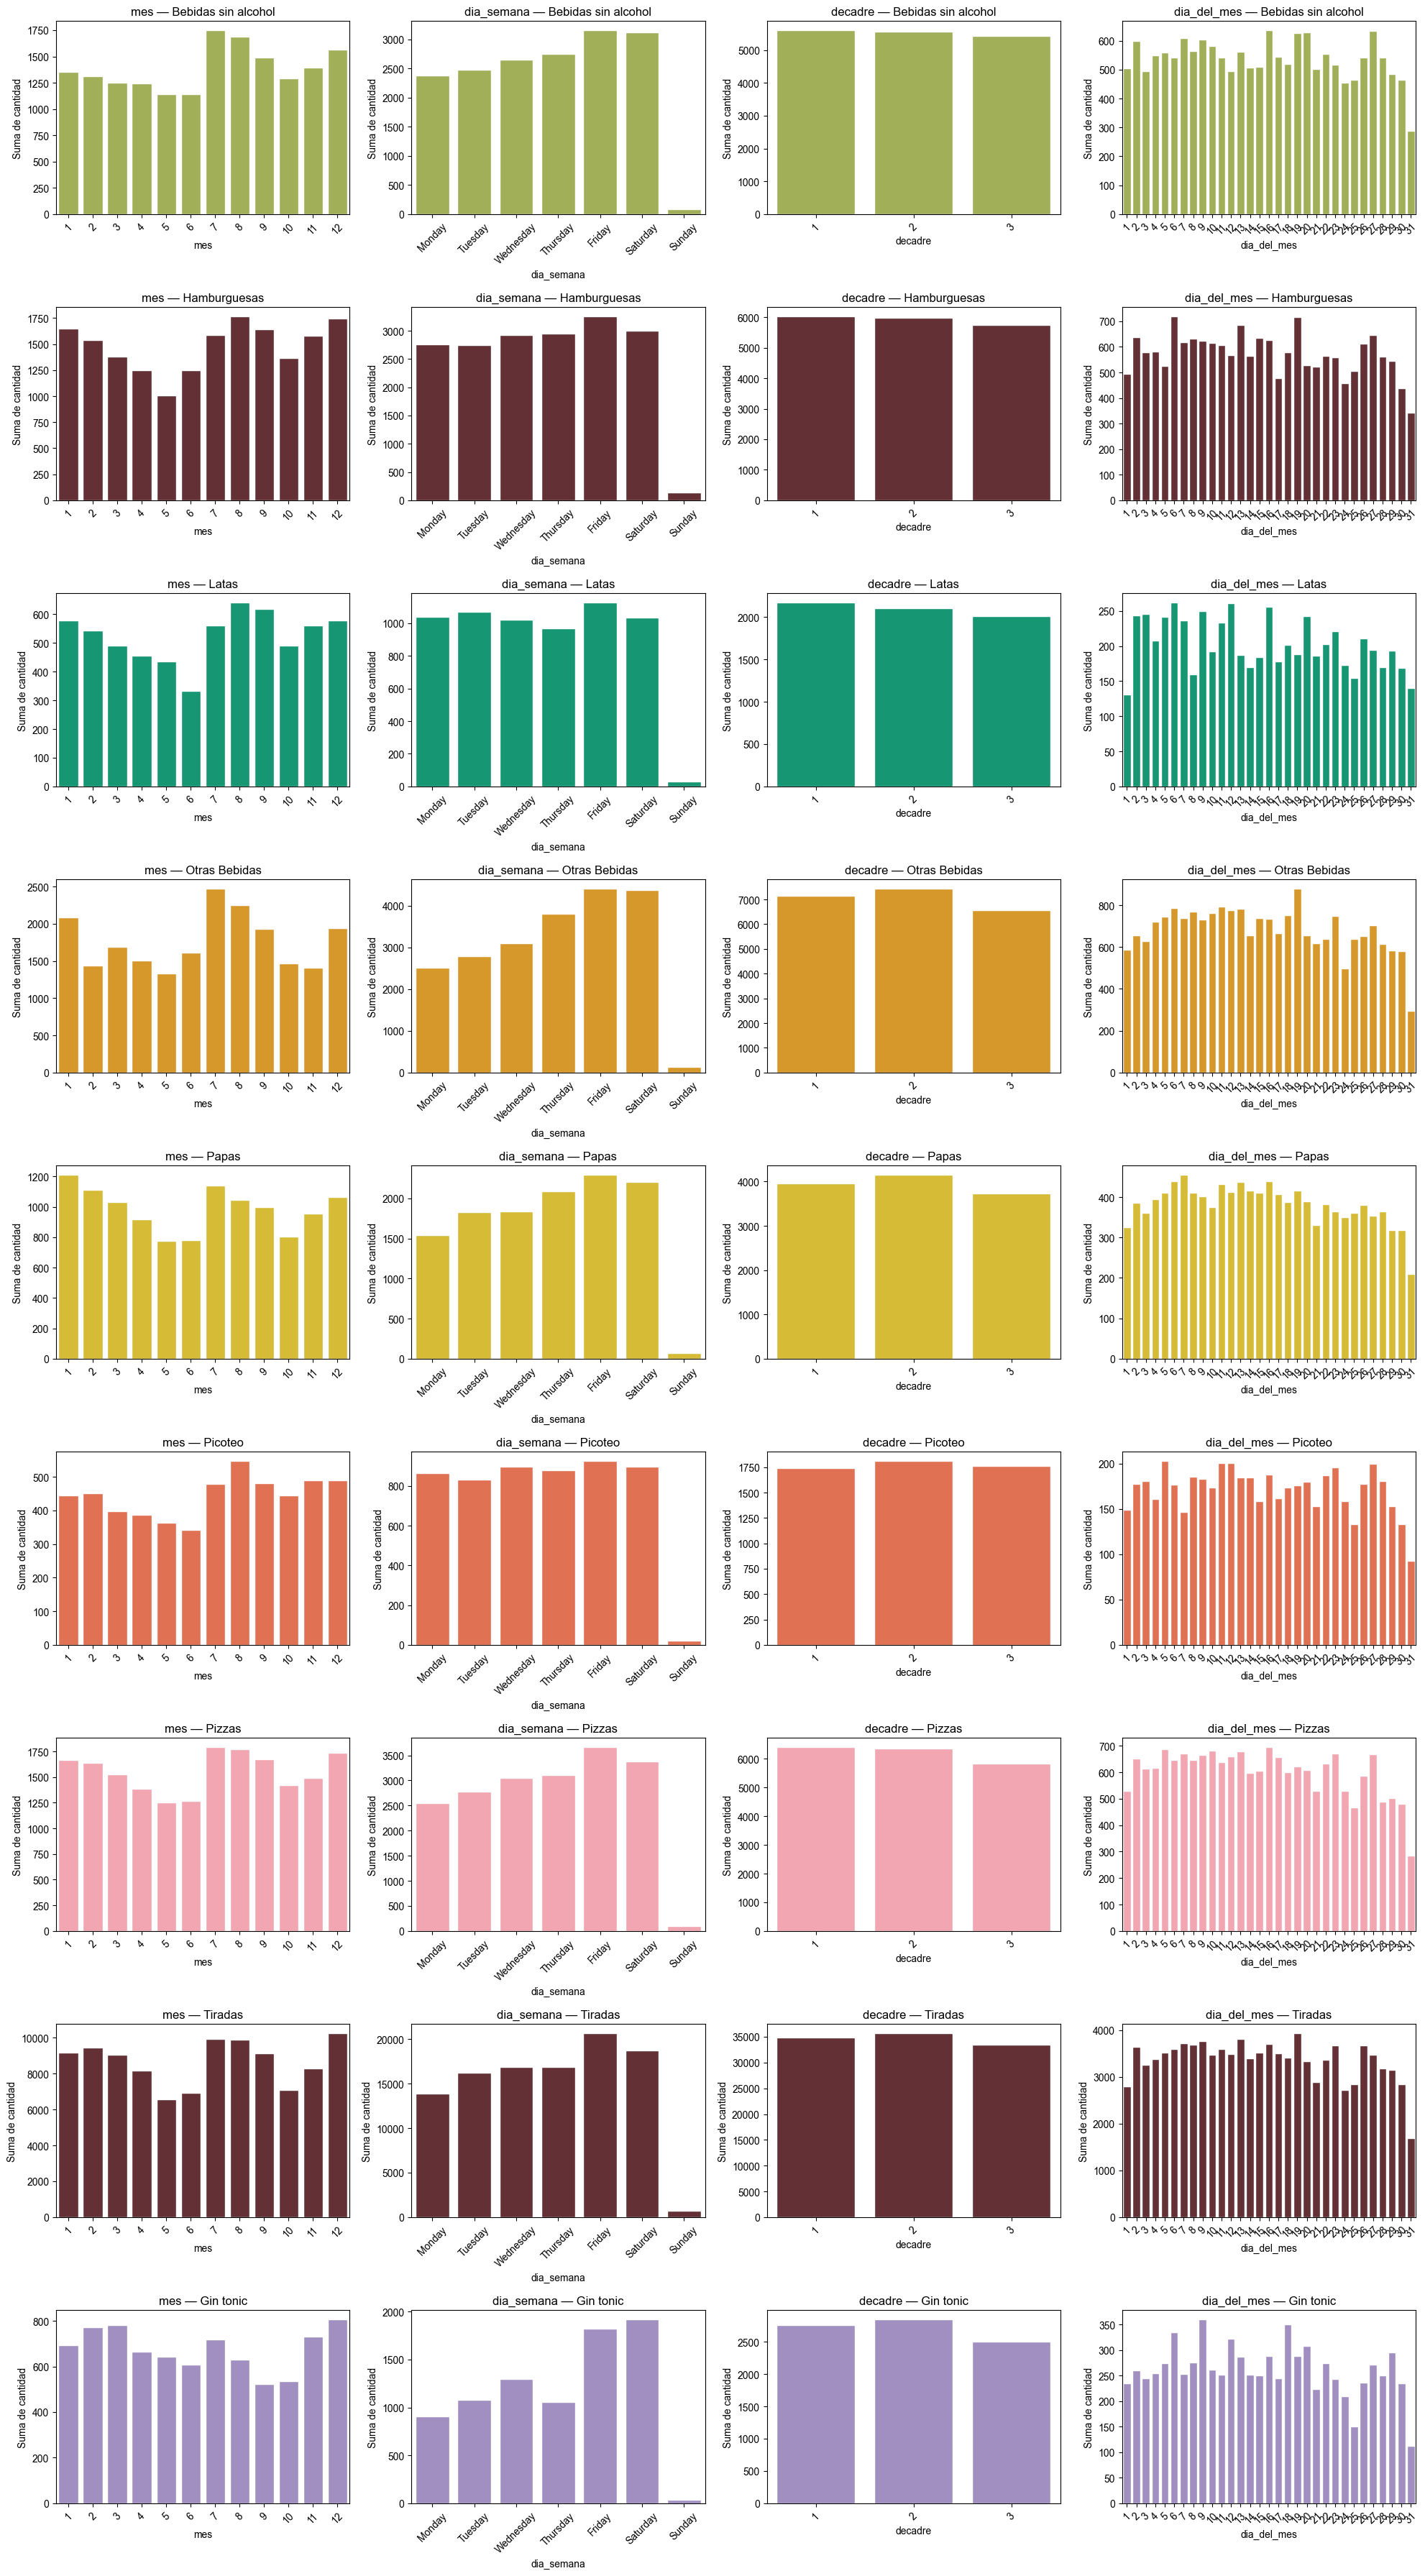

In [16]:
plot_time_sums_by_category(
    df=df_model,
    categoria_col="categoria",
    time_columns=["mes", "dia_semana", "decadre", "dia_del_mes"],
    value_col="cantidad"
)

In [17]:
df_model.groupby('categoria').cantidad.mean().sort_values(ascending=False)

categoria
Tiradas                95.200092
Otras Bebidas          19.357601
Pizzas                 17.048993
Hamburguesas           16.264652
Bebidas sin alcohol    15.217033
Papas                  10.845696
Gin tonic               7.420330
Latas                   5.760073
Picoteo                 4.868132
Name: cantidad, dtype: float64

In [18]:
df_model['dia_semana'] = df_model['fecha'].dt.dayofweek
# df_model.drop(columns='day_of_month', inplace=True)

Day-of-week and month features were evaluated as one-hot encoded variables. In this dataset, one-hot encoding did not improve generalization, so these features were retained in their original numerical representation for model stability and simplicity.

In [19]:
df_model_ohe = df_model[['fecha', 'categoria', 'mes', 'dia_semana',
                         'dia_del_mes', 'decadre',
                         'fin_de_semana', 'holiday', 'cantidad']].copy()

# Ensure date as datetime
df_model_ohe['fecha'] = pd.to_datetime(df['fecha'])

# Select categorical columns for OHE
cols_ohe = [ 'mes', 'dia_semana', 'dia_del_mes', 'decadre',]

# One-hot encoding
df_model_ohe = pd.get_dummies(df_model_ohe, columns=cols_ohe, prefix=cols_ohe)

# Reorder columns (optional): date first
cols = ['fecha'] + [c for c in df_model_ohe.columns if c != 'fecha']
df_model_ohe = df_model_ohe[cols]



df_model_ohe.head()

,fecha,categoria,fin_de_semana,holiday,cantidad,mes_1,mes_2,mes_3,mes_4,mes_5,...,dia_del_mes_25,dia_del_mes_26,dia_del_mes_27,dia_del_mes_28,dia_del_mes_29,dia_del_mes_30,dia_del_mes_31,decadre_1,decadre_2,decadre_3
0,2022-01-03,Bebidas sin alcohol,False,0,4.0,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,2022-01-03,Hamburguesas,False,0,15.0,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,2022-01-03,Latas,False,0,1.0,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,2022-01-03,Otras Bebidas,False,0,21.0,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,2022-01-03,Papas,False,0,10.0,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


A monthly aggregation experiment was also evaluated. The reduced sample size at monthly frequency materially degraded performance, so the final workflow remained at daily granularity.

In [20]:
df_model_mes = df_model.copy()
df_model_mes['fecha'] = df_model_mes['fecha'].dt.to_period("M").dt.to_timestamp()

def month_to_season(month):
    if month in [12, 1, 2]:
        return 1
    elif month in [3, 4, 5]:
        return 2
    elif month in [6, 7, 8]:
        return 3
    else:
        return 4

df_model_mes['estacion'] = df_model_mes['mes'].apply(month_to_season)

df_model_mes = df_model_mes.groupby(['fecha',
                                     'categoria',
                                     'año',
                                     'estacion']
                                  ).cantidad.sum(
                                  ).sort_values(ascending=False
                                                ).reset_index()
df_model_mes

,fecha,categoria,año,estacion,cantidad
0,2023-01-01,Tiradas,2023,1,4199.0
1,2023-12-01,Tiradas,2023,1,3929.0
2,2023-07-01,Tiradas,2023,3,3705.4
3,2023-03-01,Tiradas,2023,2,3604.0
4,2024-02-01,Tiradas,2024,1,3509.0
...,...,...,...,...,...
319,2022-01-01,Latas,2022,1,49.0
320,2022-10-01,Gin tonic,2022,4,42.0
321,2022-05-01,Gin tonic,2022,2,41.0
322,2022-11-01,Gin tonic,2022,4,39.0


## Category Deep Dive: `Tiradas` (Draft Beer)

The highest-volume category is used as an initial calibration case to inspect training dynamics and perform practical hyperparameter selection before scaling to all categories.

In [21]:
df_tiradas = df_model[df_model['categoria'] == 'Tiradas'].drop(columns='categoria').sort_values('fecha')
df_tiradas.head()

,fecha,año,mes,dia_del_mes,dia_semana,decadre,fin_de_semana,holiday,cantidad
7,2022-01-03,2022,1,3,0,1,False,0,87.0
16,2022-01-04,2022,1,4,1,1,False,0,68.0
25,2022-01-05,2022,1,5,2,1,False,0,94.0
34,2022-01-06,2022,1,6,3,1,False,0,72.0
43,2022-01-07,2022,1,7,4,1,False,0,59.0


### Methodology: Sequence Framing

A univariate or multivariate time series can be expressed as an ordered sequence:

$$s_{0}, s_{1}, s_{2}, \ldots, s_{P}$$

LSTM training requires converting this sequence into supervised input-output windows. Using a sliding window of size $T$, each sample predicts the next point from the previous $T$ observations.

This notebook implements that transformation and complements it with feature scaling. Scaling is critical for recurrent models because large differences in feature magnitude can destabilize gradients and slow or prevent convergence.

The preprocessing design (windowing + scaling + temporal ordering) ensures the model is exposed to consistent and learnable temporal structure.


In [22]:
# Scale each feature correctly
features = ['cantidad', 'año', 'mes',
            'dia_del_mes', 'dia_semana',
            'decadre', 'fin_de_semana',
            'holiday']
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_tiradas[features])

In [23]:
df_scaled

array([[0.34387352, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.2687747 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.3715415 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.55731225, 1.        , 1.        , ..., 1.        , 0.        ,
        0.        ],
       [0.58102767, 1.        , 1.        , ..., 1.        , 1.        ,
        0.        ],
       [0.2687747 , 1.        , 1.        , ..., 1.        , 1.        ,
        0.        ]], shape=(1092, 8))

In [24]:
# We define the size of the window
sequence_length = 15
X, y = [], []

for i in range(len(df_scaled) - sequence_length):
    X.append(df_scaled[i:i+sequence_length])
    y.append(df_scaled[i+sequence_length][0])

X, y = np.array(X), np.array(y)

### Temporal Train-Test Split

In [25]:
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


### Model Architecture and Training Strategy

A stacked LSTM architecture is used to capture short- and medium-term dependencies. The model combines sequence-level representation learning with a final dense regressor for next-step prediction. Training uses MSE optimization with Adam and early stopping to reduce overfitting risk.

In [26]:
n_features = X.shape[2]

# Sequential model
model = Sequential([
    Input(shape=(sequence_length, n_features)),
    LSTM(32, return_sequences=True),
    LSTM(16),
    Dense(1)
])

model.compile(loss='mse', optimizer=Adam(0.001))


# Early stop
early = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=8,
    callbacks=[early],
    verbose=1
)

Epoch 1/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0660 - val_loss: 0.0376
Epoch 2/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0503 - val_loss: 0.0350
Epoch 3/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0446 - val_loss: 0.0318
Epoch 4/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0377 - val_loss: 0.0349
Epoch 5/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0320 - val_loss: 0.0175
Epoch 6/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0294 - val_loss: 0.0176
Epoch 7/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0275 - val_loss: 0.0193
Epoch 8/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0268 - val_loss: 0.0206
Epoch 9/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0265 - val_loss: 0.0182
Epoch 10/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0253 - val_loss: 0.0195
Epoch 11/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0246 - val_loss: 0.0221
Epoch 12/200
108/108 ━━━━━━━━━━━━━━━━━━━━

### Training Diagnostics

Loss curves are monitored to evaluate convergence and generalization. The train/validation trajectories show stable optimization with limited divergence, indicating controlled overfitting under the selected configuration.

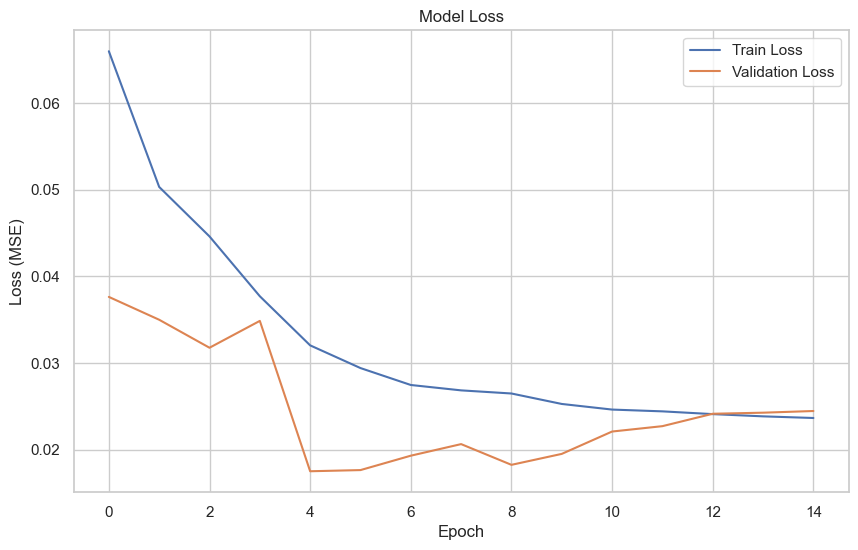

In [27]:
# Visualization of the loss function during training
plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Request with the trained model
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


### Results and Analysis

In [29]:
# Measure precision
training_error = model.evaluate(X_train, y_train, verbose=0)
print('Training error = {:.2f}%'.format(training_error*100))

testing_error = model.evaluate(X_test, y_test, verbose=0)
print('Error de test = {:.2f}%'.format(testing_error*100))


# calculate root mean squared error
print('RMSE in training = %.2f' % (np.sqrt(training_error)))
print('RMSE en test = %.2f' % (np.sqrt(testing_error)))


Error de entrenamiento = 2.77% 
Error de test = 1.75%
RMSE en entrenamiento = 0.17
RMSE en test = 0.13


In [30]:
venta_original = df_tiradas[['cantidad']].values.ravel()
train_predict_sc = scaler.inverse_transform(
    np.hstack([
        train_predict.reshape(-1,1),
        np.zeros((len(train_predict), X.shape[2]-1))
    ])
)[:,0]

y_test_sc = scaler.inverse_transform(
    np.concatenate([
        y_test.reshape(-1, 1),
        np.zeros((len(y_test), scaler.n_features_in_ - 1))
    ], axis=1)
)[:, 0]

test_predict_sc = scaler.inverse_transform(
    np.hstack([
        test_predict.reshape(-1,1),
        np.zeros((len(test_predict), X.shape[2]-1))
    ])
)[:,0]


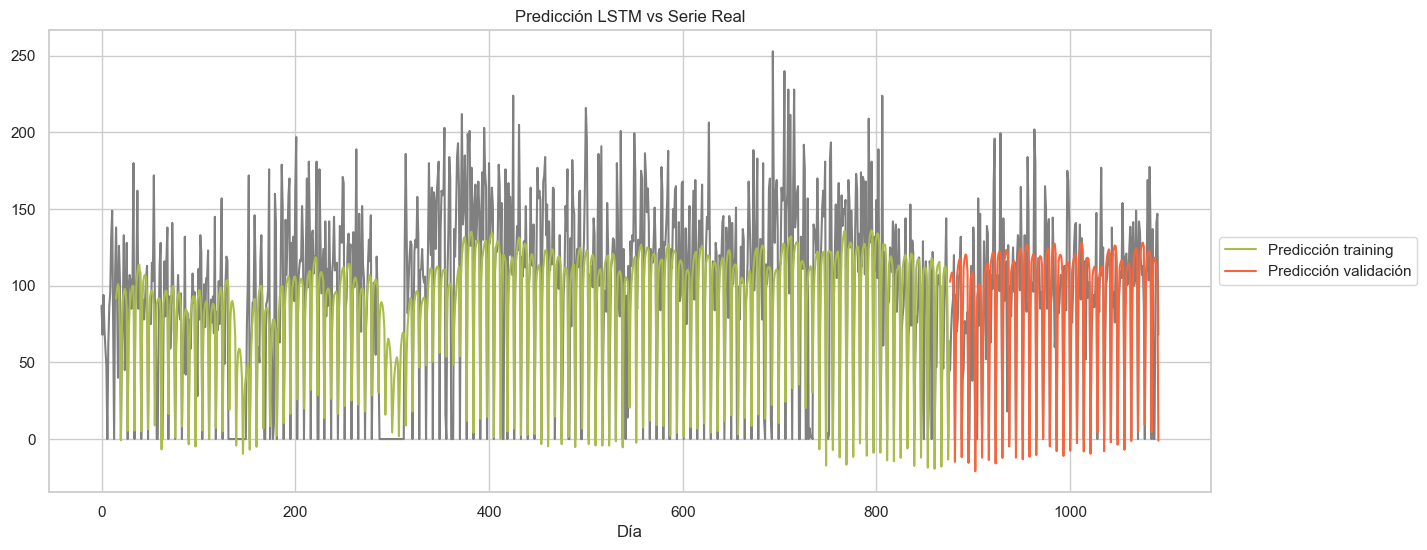

In [31]:
plt.figure(figsize=(15, 6))

# royal series
plt.plot(venta_original, color='grey')

# Point where the train prediction starts
train_start = sequence_length
train_end = train_start + len(train_predict_sc)

# Train
plt.plot(
    np.arange(train_start, train_end),
    train_predict_sc,
    color=paleta[0],
    label='Predicción training'
)

# Test
test_start = train_end
test_end = test_start + len(test_predict_sc)

plt.plot(
    np.arange(test_start, test_end),
    test_predict_sc,
    color=paleta[5],
    label='Predicción validación'
)

# Labels and legend
plt.xlabel('Día')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("LSTM Prediction vs Real Series")

plt.show()


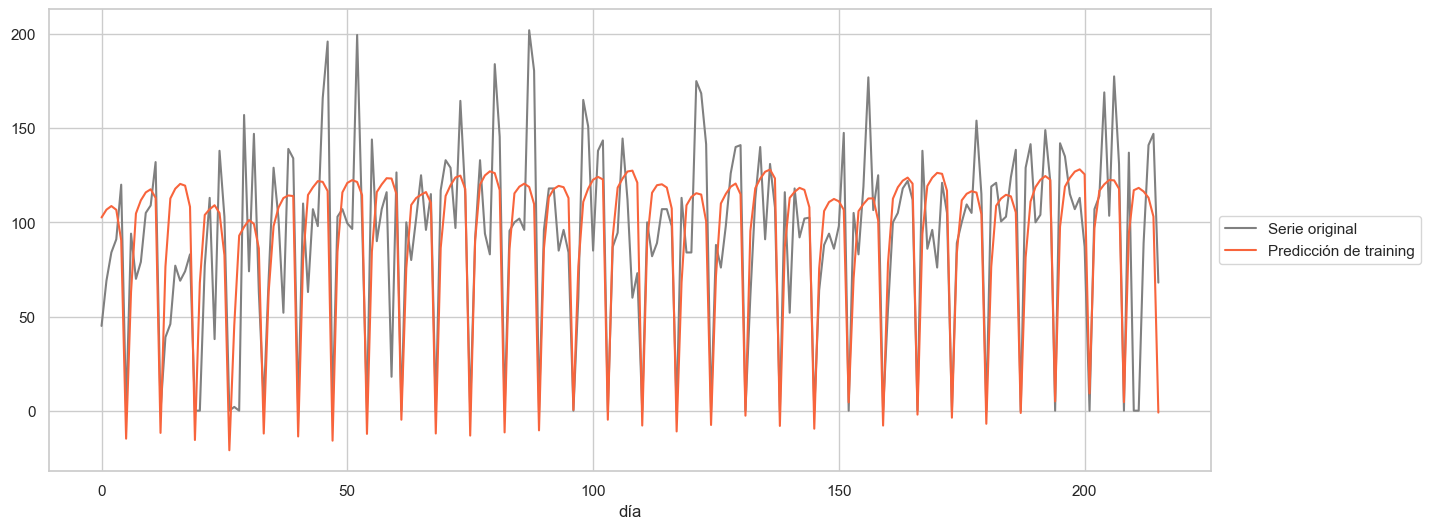

In [32]:
plt.figure(figsize=(15, 6))

# Plot original series
plt.plot(y_test_sc, color = 'grey')

# Plot validation prediction
plt.plot(test_predict_sc, color = paleta[5])

# Add labels
plt.xlabel('día')
plt.legend(['Serie original','Training prediction','Validation prediction'],loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [33]:
# Results
mae_test = mean_absolute_error(y_test_sc, test_predict_sc)
rmse_test = root_mean_squared_error(y_test_sc, test_predict_sc)
r2_test = r2_score(y_test_sc, test_predict_sc)

print(f"MAE Test: {mae_test:.2f}")
print(f"RMSE Test: {rmse_test:.2f}")
print(f"R2 Test: {r2_test:.2f}")

MAE Test: 25.75
RMSE Test: 33.47
R2 Test: 0.55


The baseline model reaches MAE = 25.75, RMSE = 33.47, and R² = 0.55 on the test split. This indicates partial capture of temporal dynamics, with clear degradation on high-demand peaks. In operational terms, median-day forecasting is usable, but peak management remains a key improvement area.

### Hyperparameter Optimization

Hyperparameter tuning focuses on epochs and batch size because both directly affect convergence behavior, optimization noise, and overfitting risk. The objective is to identify a configuration that balances stability and predictive quality.

In [34]:
def LSTM_model(learning_rate=0.001):
  model = Sequential([
    Input(shape=(sequence_length, n_features)),
    LSTM(32, return_sequences=True),
    LSTM(16),
    Dense(1)
])

  optimizer = Adam(learning_rate=learning_rate)
  model.compile(loss='mean_squared_error', optimizer=optimizer)
  return model

In [35]:
# We define the range of hyperparameters for the "grid search"
batch_sizes = [1, 5, 7, 10]
epochs_list = [75, 100, 120, 150]

In [36]:
# Dataframe to save the results
results = []

# Grid search loop
start_time_all = time.time()
for batch_size in batch_sizes:
    for epochs in epochs_list:
        print(f"Training with batch_size={batch_size} and epochs={epochs}")

        # We create the model
        model = LSTM_model(learning_rate=0.001)

        # ---------- measure time ----------
        start_time = time.time()
        # ----------------------------------

        # Model fit
        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(X_test, y_test),
            verbose=0
        )

        # ---------- end of time ----------
        end_time = time.time()
        elapsed_time = end_time - start_time
        # -------------------------------------

        # Test evaluation
        y_pred = model.predict(X_test)
        mse = model.evaluate(X_test, y_test, verbose=0)

        # We save the results
        results.append({
            'batch_size': batch_size,
            'epochs': epochs,
            'mse': mse,
            'time_seconds': elapsed_time,
            'history': history.history
        })

        print(f"Score (MSE): {mse:.4f} | Tiempo: {elapsed_time:.2f} segundos")
end_time_all = time.time()
elapsed_time = end_time_all - start_time_all
print(f"Tiempo total: {elapsed_time:.2f} segundos")

Training with batch_size=1 and epochs=75
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Score (MSE): 0.0273 | Tiempo: 90.56 segundos
Training with batch_size=1 and epochs=100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Score (MSE): 0.0320 | Tiempo: 115.78 segundos
Training with batch_size=1 and epochs=120
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Score (MSE): 0.0272 | Tiempo: 138.23 segundos
Training with batch_size=1 and epochs=150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Score (MSE): 0.0244 | Tiempo: 172.42 segundos
Training with batch_size=5 and epochs=75
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Score (MSE): 0.0320 | Tiempo: 25.72 segundos
Training with batch_size=5 and epochs=100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Score (MSE): 0.0334 | Tiempo: 34.29 segundos
Training with batch_size=5 and epochs=120
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Score (MSE): 0.0408 | Tiempo: 40.71 segundos
Training with batch_size=5 and epochs=150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Score (MSE): 0.0417 | Tiempo: 51.20 segundos

In [37]:
# Results of the fitted models
results_df = pd.DataFrame(results)
results_df[['batch_size', 'epochs', 'mse']]

,batch_size,epochs,mse
0,1,75,0.027349
1,1,100,0.032034
2,1,120,0.027160
3,1,150,0.024435
4,5,75,0.031962
5,5,100,0.033379
6,5,120,0.040829
7,5,150,0.041704
8,7,75,0.026871
9,7,100,0.056826


In [38]:
# We are left with the best model
best_model = results_df.loc[results_df['mse'].idxmin()]

print(f"Model with best socre (MSE): {best_model['mse']}")
print('RMSE en test  %.2f' % (np.sqrt(best_model['mse'])))
print(f"Best model parameters: batch_size={best_model['batch_size']}, /epochs={best_model['epochs']}")


Modelo con mejor socre (MSE): 0.024435384199023247
RMSE en test  0.16
Parámetros del mejor modelo: batch_size=1, /epochs=150


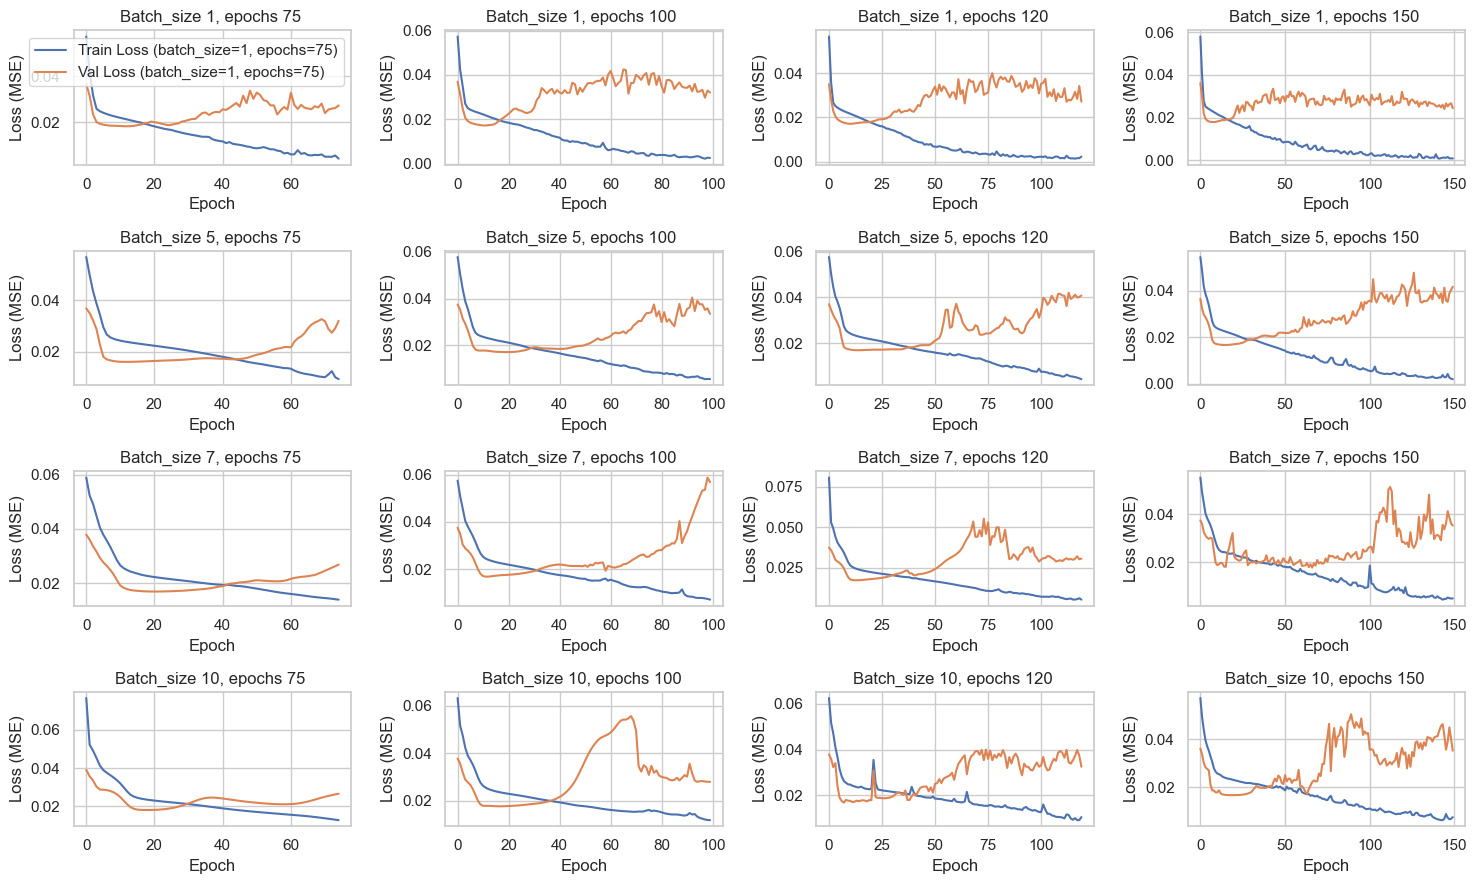

In [39]:
# We define the dimensions of the grid
num_rows = 4
num_cols = 4

# We create the figure and specify the total size
plt.figure(figsize=(15, 9))  # Ajusta el tamaño según tus preferencias

# We create subplots
for i, result in enumerate(results):

    history = result['history']
    label = f"batch_size={result['batch_size']}, epochs={result['epochs']}"

    # We calculate the position of the subplot on the grid
    plt.subplot(num_rows, num_cols, i + 1)

    # We plot the training and validation loss
    plt.plot(history['loss'], label=f"Train Loss ({label})")
    plt.plot(history['val_loss'], label=f"Val Loss ({label})")

    # We add title and labels of the axes
    plt.title(f"Batch_size {result['batch_size']}, epochs {result['epochs']} ")
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')

    # We show the legend only in the first subplot
    if i == 0:
        plt.legend(loc='upper right')

    # We activate the grid in each subplot
    plt.grid(True)

# We automatically adjust the spacing between subplots
plt.tight_layout()

# We show the final figure with all the subplots
plt.show()


The tuning sweep shows meaningful sensitivity to the `(batch_size, epochs)` combination. The best configuration in this notebook achieves the lowest MSE with moderate training length, while overly long training tends to degrade validation performance.

## Multicategory Modeling

To maintain execution scalability, the best configuration from the calibration category is applied to all categories. This is a practical engineering tradeoff: reduced tuning cost at the expense of category-specific optimality.

In [40]:
df_model.columns

Index(['fecha', 'categoria', 'año', 'mes', 'dia_del_mes', 'dia_semana',
       'decadre', 'fin_de_semana', 'holiday', 'cantidad'],
      dtype='str')

---- Preprocess Bebidas sin alcohol ----
---- Modelo Bebidas sin alcohol ajustado ----


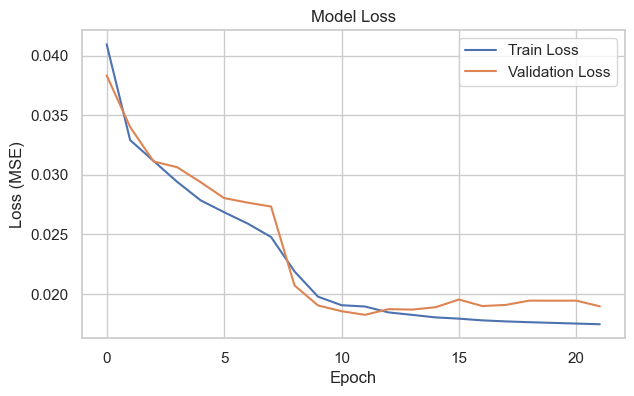

---- Preprocess Hamburguesas ----
---- Modelo Hamburguesas ajustado ----


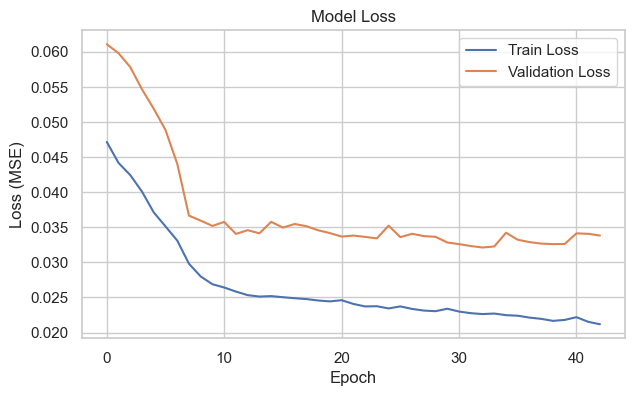

---- Preprocess Latas ----
---- Modelo Latas ajustado ----


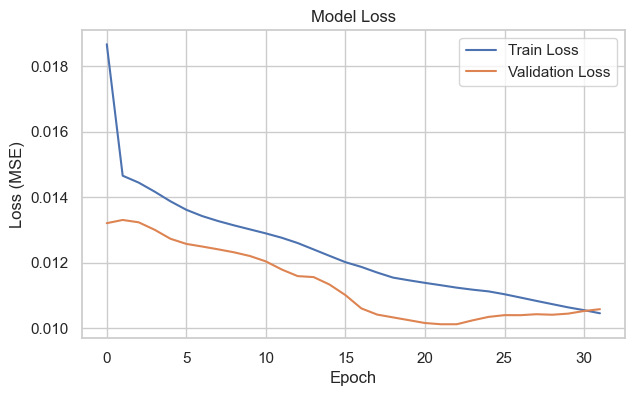

---- Preprocess Otras Bebidas ----
---- Modelo Otras Bebidas ajustado ----


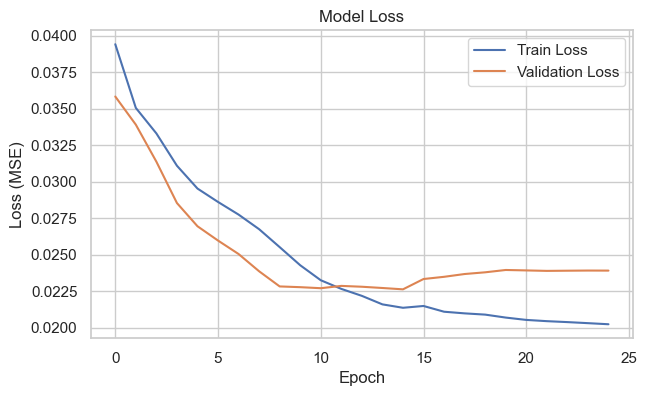

---- Preprocess Papas ----
---- Modelo Papas ajustado ----


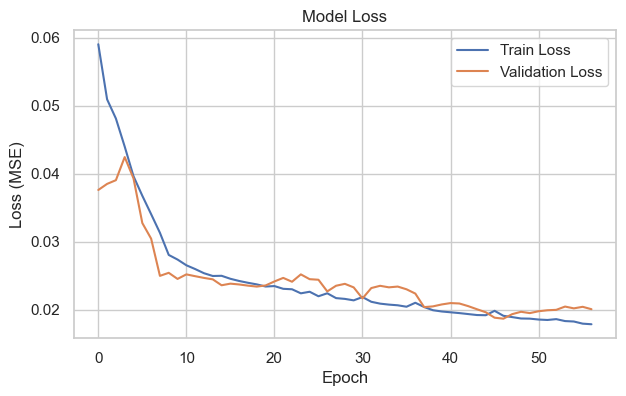

---- Preprocess Picoteo ----
---- Modelo Picoteo ajustado ----


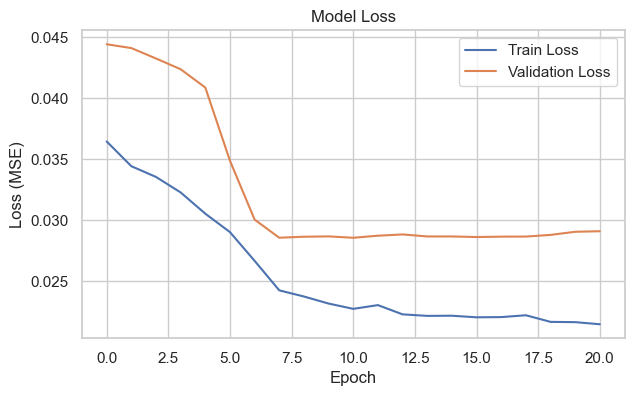

---- Preprocess Pizzas ----
---- Modelo Pizzas ajustado ----


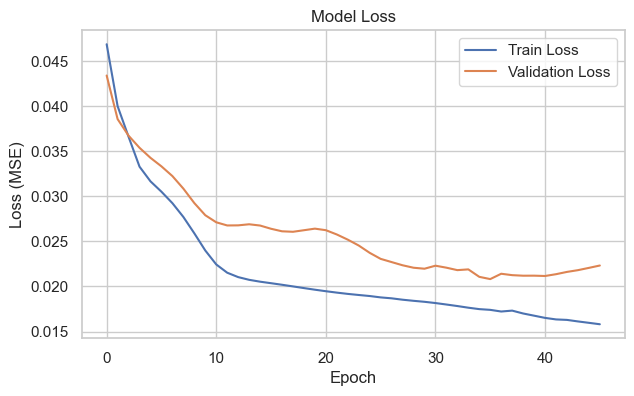

---- Preprocess Tiradas ----
---- Modelo Tiradas ajustado ----


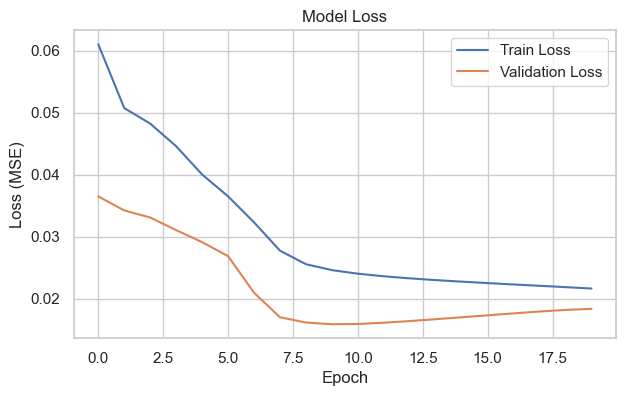

---- Preprocess Gin tonic ----
---- Modelo Gin tonic ajustado ----


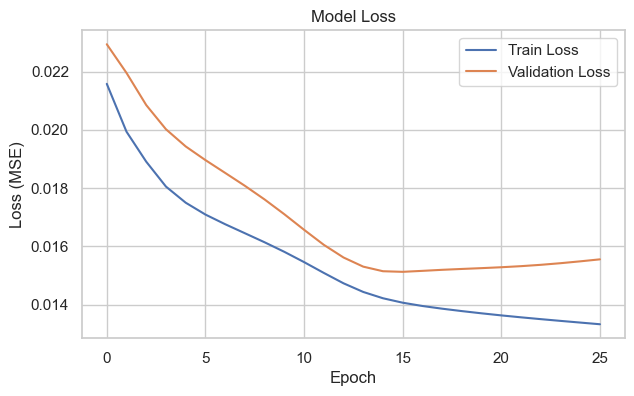

In [41]:
cutoff='2024-10-01'
sequence_length = 15
features = ['cantidad', 'año', 'mes',
            'dia_del_mes', 'dia_semana',
            'decadre', 'fin_de_semana', 'holiday']
categorias = df_model['categoria'].unique()
resultados = []
df_pred_cat = []

for cat in categorias:
  print(f'---- Preprocess {cat} ----')
  # Preprocessing
  (X_train, X_test,
   y_train, y_test,
   scaler,
   fechas_test) = preprocess_data_por_cat(df_model,
                                          cat,
                                          cutoff,
                                          sequence_length=sequence_length)

  print(f'---- Model {cat} adjusted ----')
  # Model training
  mse, mae_test, rmse_test, r2_test, df_pred = model_fit_por_categoria(
      X_train, X_test, y_train, y_test, fechas_test,
      sequence_length=sequence_length,
      n_features=X_train.shape[2],
      scaler=scaler,
      categoria=cat,
      epochs=75,
      batch_size=10
  )

  # Save metrics
  resultados.append({
      'categoria': cat,
      'mse': mse,
      'mae': mae_test,
      'rmse': rmse_test,
      'r2_test': r2_test
  })

  # Save predictions
  df_pred_cat.append(df_pred)

# Convert results to DataFrame
df_metricas_cat = pd.DataFrame(resultados)

# Combine all predictions
df_pred_category = pd.concat(df_pred_cat, ignore_index=True)



Early stopping behavior varies by category, reflecting heterogeneous signal-to-noise ratios and seasonality profiles. Faster convergence generally corresponds to more stable categories, while volatile categories require longer optimization paths.

In [42]:
df_metricas_cat

,categoria,mse,mae,rmse,r2_test
0,Bebidas sin alcohol,0.018255,5.712148,7.566234,0.451539
1,Hamburguesas,0.032123,6.528808,8.602946,0.479687
2,Latas,0.010119,3.877069,4.928957,0.235141
3,Otras Bebidas,0.022631,9.114184,12.185423,0.342090
4,Papas,0.018691,2.933401,4.238145,0.501789
5,Picoteo,0.028566,2.456246,3.211259,0.349520
6,Pizzas,0.020821,5.971527,7.647704,0.509854
7,Tiradas,0.015850,23.101819,31.852347,0.555527
8,Gin tonic,0.015124,4.744455,6.395032,0.313360


Best-performing categories by error metrics include Tiradas, Hamburguesas, and Papas. Lower-performing categories include Latas, Gin tonic, and Picoteo, where volatility and sparse peak patterns reduce explainability.

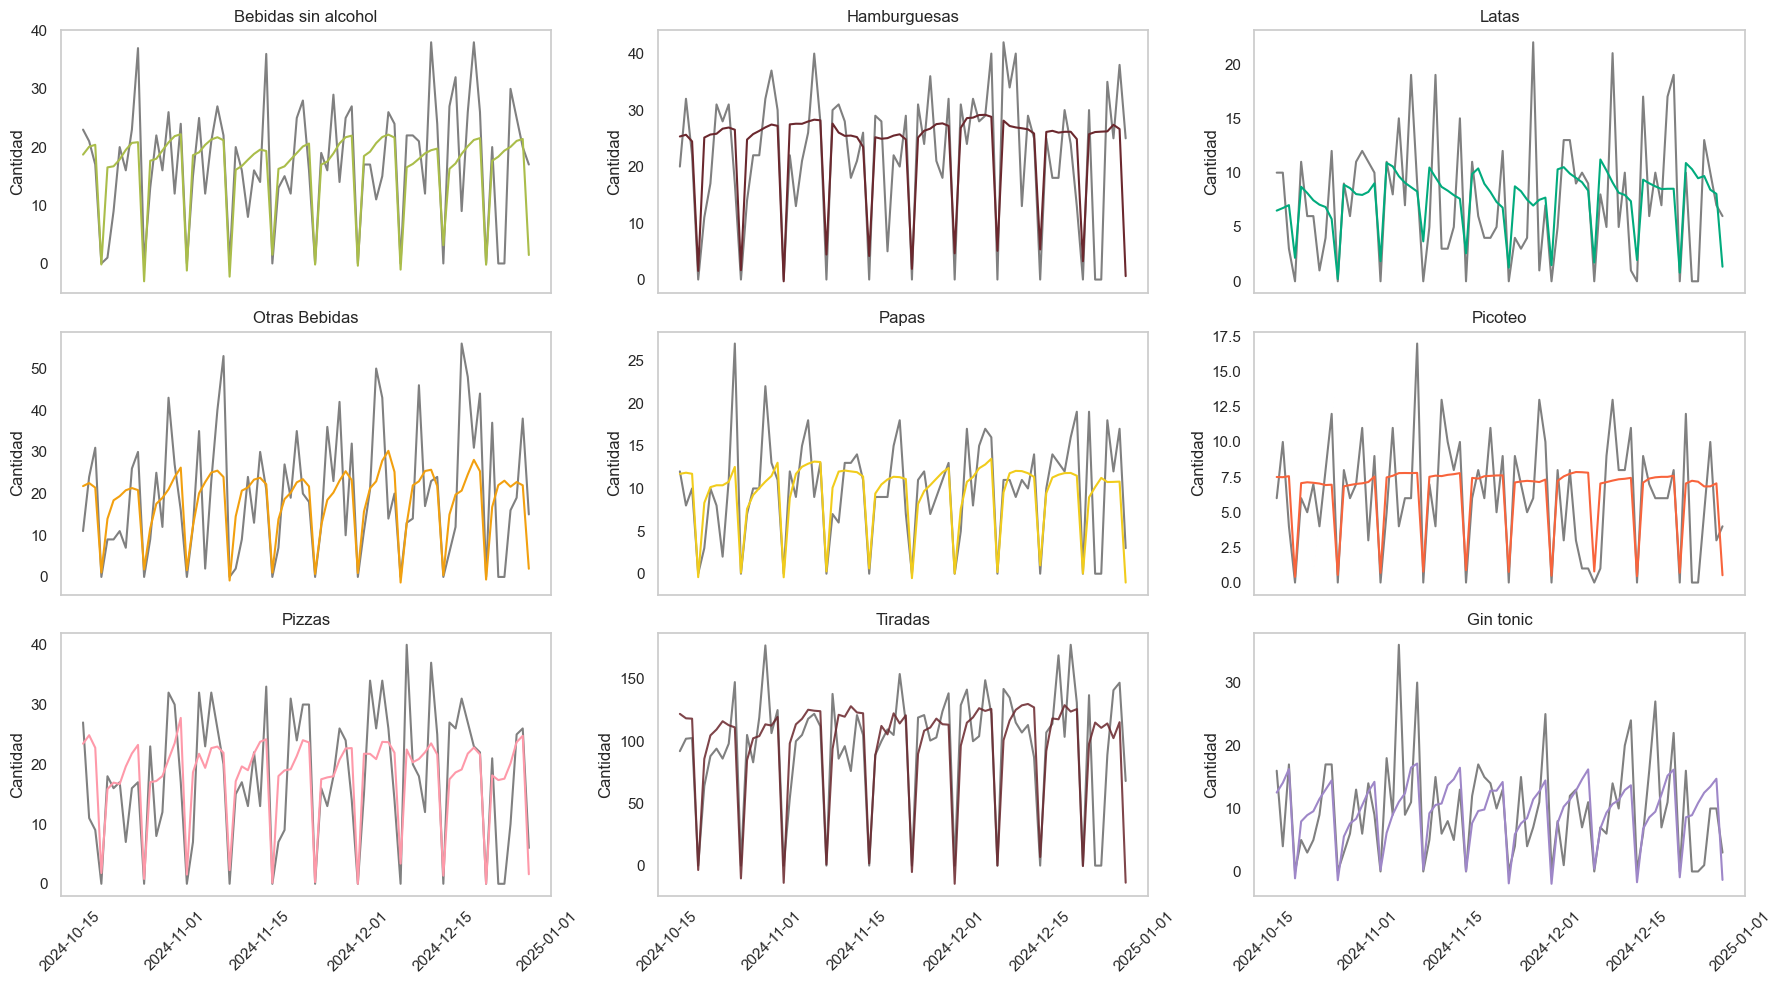

In [43]:
plot_predicciones_por_categoria(df_pred_category, n_cols=3, figsize=(18, 10))

Temporal plots show a recurring pattern: models capture baseline levels and troughs more reliably than spikes, resulting in systematic underestimation during high-demand windows.

## Log-Transformation Experiment

A log-transformed target experiment was tested to reduce variance and dampen extreme values. The hypothesis was improved stability and better peak handling.

---- Preprocess Bebidas sin alcohol ----
---- Modelo Bebidas sin alcohol ajustado ----


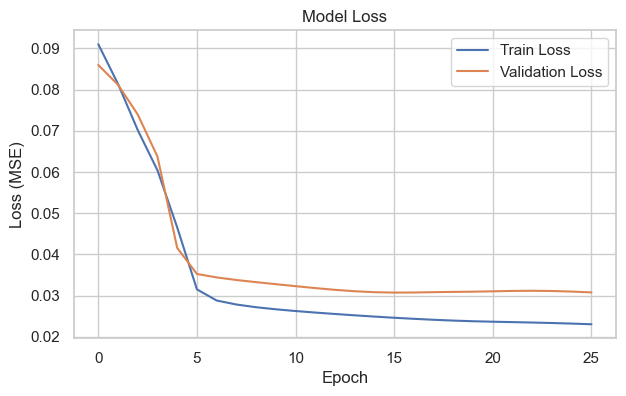

---- Preprocess Hamburguesas ----
---- Modelo Hamburguesas ajustado ----


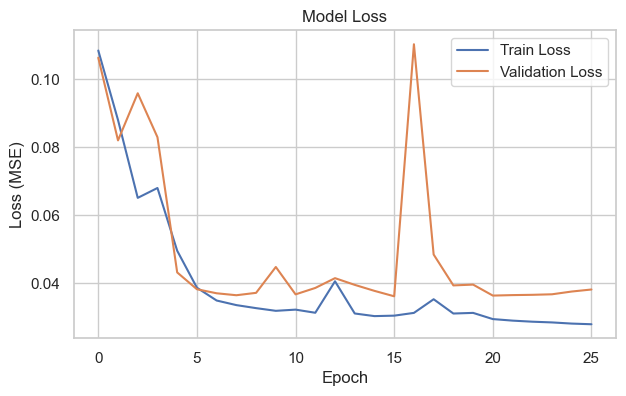

---- Preprocess Latas ----
---- Modelo Latas ajustado ----


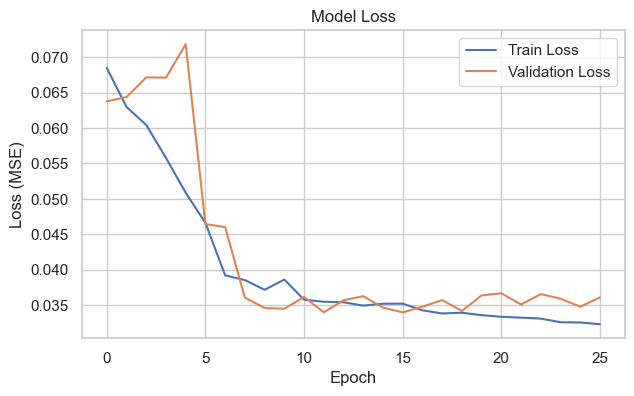

---- Preprocess Otras Bebidas ----
---- Modelo Otras Bebidas ajustado ----


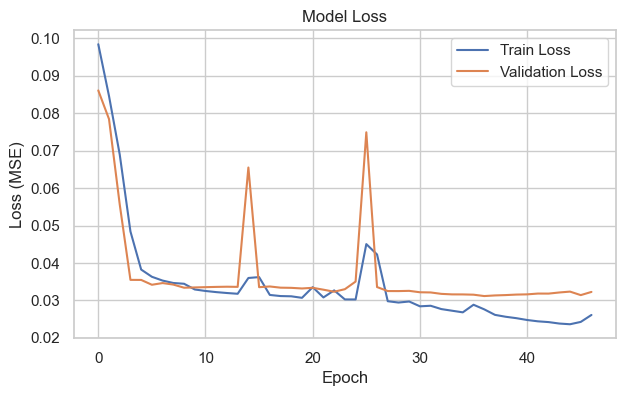

---- Preprocess Papas ----
---- Modelo Papas ajustado ----


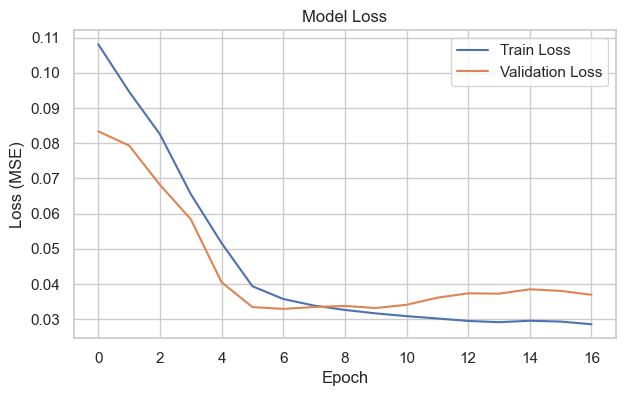

---- Preprocess Picoteo ----
---- Modelo Picoteo ajustado ----


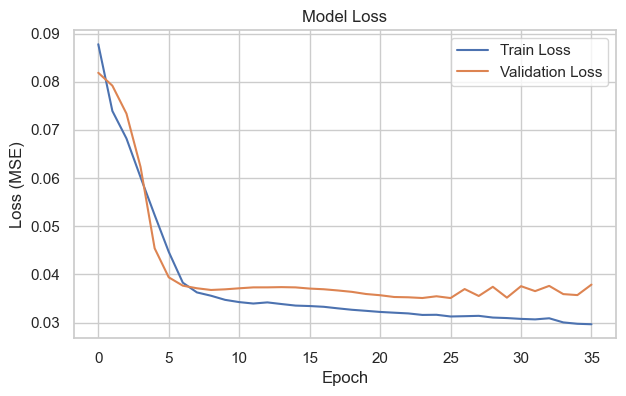

---- Preprocess Pizzas ----
---- Modelo Pizzas ajustado ----


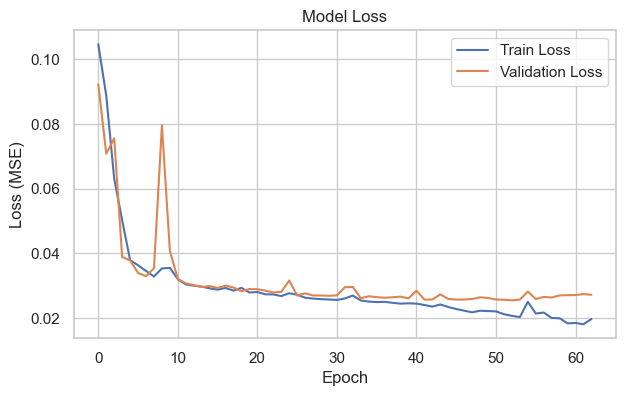

---- Preprocess Tiradas ----
---- Modelo Tiradas ajustado ----


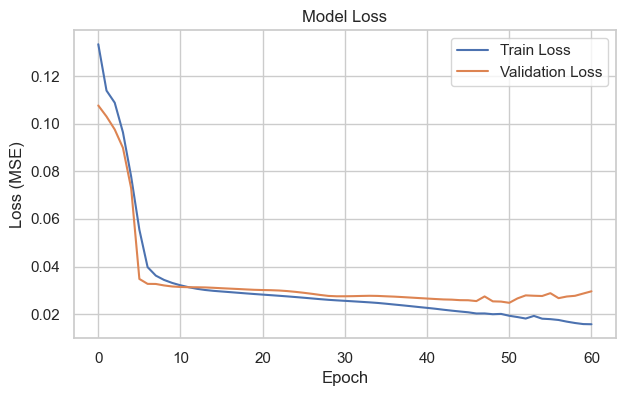

---- Preprocess Gin tonic ----
---- Modelo Gin tonic ajustado ----


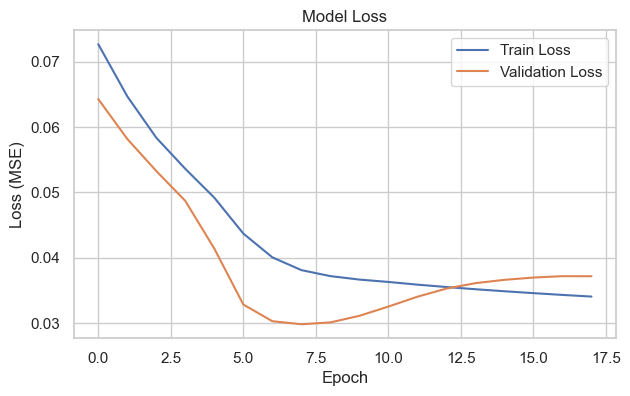

In [44]:
cutoff='2024-10-01'
sequence_length = 15
features = ['cantidad', 'año', 'mes',
            'dia_del_mes', 'dia_semana',
            'decadre', 'fin_de_semana', 'holiday']
categorias = df_model['categoria'].unique()
resultados = []
df_pred_cat = []

for cat in categorias:
  print(f'---- Preprocess {cat} ----')
  # Preprocessing
  (X_train, X_test,
   y_train, y_test,
   scaler,
   fechas_test) = preprocess_data_por_cat(df_model,
                                          cat,
                                          cutoff,
                                          sequence_length=sequence_length,
                                          use_log=True)

  print(f'---- Model {cat} adjusted ----')
  # Model training
  mse, mae_test, rmse_test, r2_test, df_pred = model_fit_por_categoria(
      X_train, X_test, y_train, y_test, fechas_test,
      sequence_length=sequence_length,
      n_features=X_train.shape[2],
      scaler=scaler,
      categoria=cat,
      epochs=120,
      batch_size=5,
      use_log=True
  )

  # Save metrics
  resultados.append({
      'categoria': cat,
      'mse': mse,
      'mae': mae_test,
      'rmse': rmse_test,
      'r2_test': r2_test
  })

  # Save predictions
  df_pred_cat.append(df_pred)

# Convert results to DataFrame
df_metricas_log = pd.DataFrame(resultados)

# Combine all predictions
df_pred_category_log = pd.concat(df_pred_cat, ignore_index=True)



In [45]:
df_metricas_log

,categoria,mse,mae,rmse,r2_test
0,Bebidas sin alcohol,0.030721,6.558953,8.900548,0.241038
1,Hamburguesas,0.036217,8.432426,10.964463,0.154829
2,Latas,0.033997,4.159000,5.910425,-0.099788
3,Otras Bebidas,0.031170,9.069985,12.841314,0.269359
4,Papas,0.032949,4.257036,5.835558,0.055448
5,Picoteo,0.035079,2.419441,3.347607,0.293109
6,Pizzas,0.025469,6.465632,8.225853,0.432945
7,Tiradas,0.024750,27.357507,37.192714,0.393992
8,Gin tonic,0.029796,4.701971,6.542932,0.281233


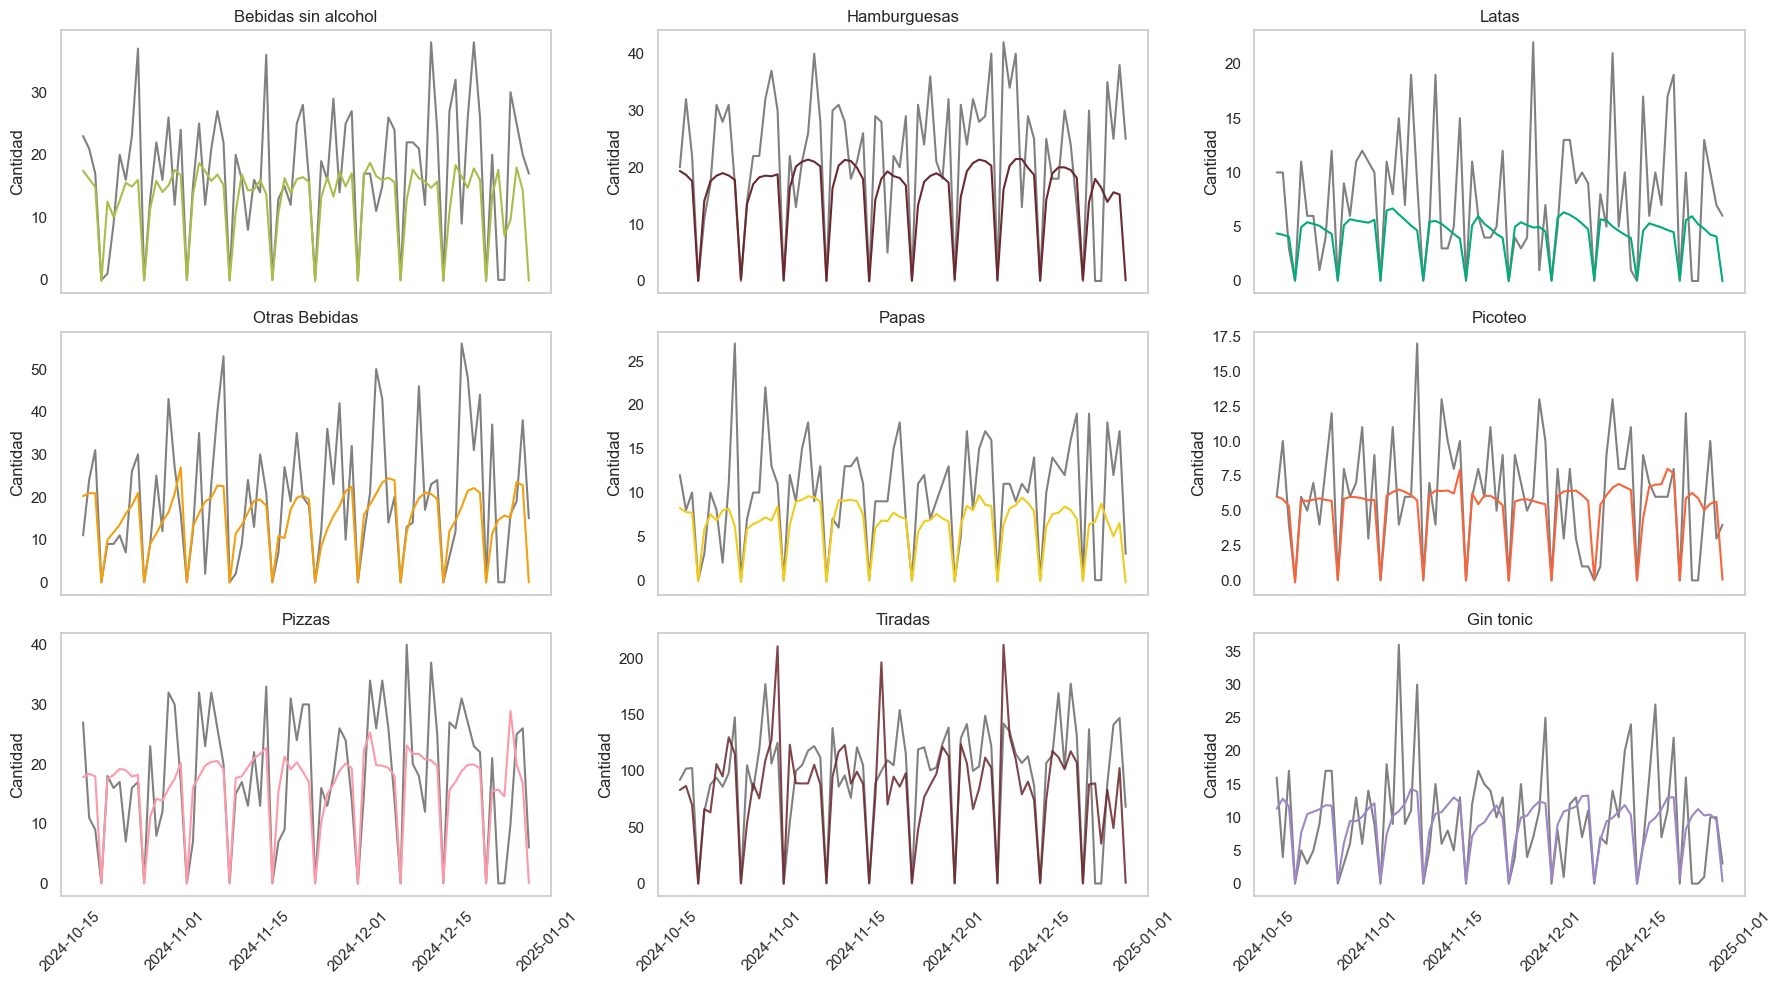

In [46]:
plot_predicciones_por_categoria(df_pred_category_log, n_cols=3, figsize=(18, 10))

The log-transform experiment did not improve aggregate performance and degraded some categories, so it was not adopted in the final configuration.

## Key Insights

1. LSTM is a strong baseline for category-level daily forecasting but underestimates extremes.
2. Category-specific behavior dominates model quality, so one-size-fits-all tuning is limited.
3. Additional external and business-context features are likely required for peak-demand prediction.
4. Per-category hyperparameter optimization is a high-impact next step.

## Conclusion and References

The LSTM workflow provides a technically sound baseline and clear diagnostic visibility. For portfolio and production relevance, the next iteration should prioritize category-specific tuning, richer exogenous features, and alternative architectures better suited for sharp demand spikes.

### References

- https://arxiv.org/pdf/2101.03087
- https://machinelearningmastery.com/time-series-prediction-lstm-recurrent-neural-networks-python-keras/
- https://www.kaggle.com/code/ritesh7355/develop-lstm-models-for-time-series-forecasting
- https://keras.io/api/layers/recurrent_layers/lstm/